# Figure S2 — Filtering of the 10 kb TSS regions

**Panels** — (a) genomic coverage of the ENCODE blacklist vs the (more
conservative) GC-correction exclusion list, per chromosome; (b) Venn diagram
of TSS windows overlapping each blacklist; (c) per-TSS mean vs standard
deviation of coverage across the panel-of-normals, colored by filter
category.

**Source data** (no pickles, no cluster paths, no network):
- `data/figS2a_blacklist_per_chrom.csv` — bp per chromosome per blacklist
  (raw interval-length sums, as in the original analysis).
- `data/figS2b_venn_counts.csv` — overlapping-entry counts.
- `data/figS2c_tss_qc.csv` — one row per TSS window: PoN coverage mean/SD and
  filter-category membership (blacklist / overlapping TSS < 5 kb / chrX /
  high variability), validated by the exporter against the panel's counts
  (total 19,376; removed 5,152; retained 14,224; 452 removed by multiple
  filters).

Written by `export/export_figS2.py`. The notebook that drew the submitted
S2c panel was not found in the repository; this panel is a faithful
reconstruction from the validated filter artifacts (all category counts
reproduce the submitted figure exactly). Run top to bottom from `src/figures/`.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from scipy import stats

s2a = pd.read_csv("data/figS2a_blacklist_per_chrom.csv")
s2b = pd.read_csv("data/figS2b_venn_counts.csv")
s2c = pd.read_csv("data/figS2c_tss_qc.csv")
print(f"S2c: {len(s2c)} windows, removed {int(s2c['removed'].sum())}, "
      f"retained {int((~s2c['removed']).sum())}")

S2c: 19376 windows, removed 5152, retained 14224


## Panel a — blacklist coverage per chromosome

In [2]:
def chrom_sort_key(c):
    v = c.replace("chr", "")
    return 23 if v == "X" else int(v)


def panel_a(ax):
    d = s2a.copy()
    d["order"] = d["chrom"].map(chrom_sort_key)
    d = d.sort_values("order", ascending=False)
    y = np.arange(len(d))
    h = 0.4
    ax.barh(y + h / 2, d["encode_blacklist_bp"], height=h, color="#440154",
            label="ENCODE Blacklist")
    ax.barh(y - h / 2, d["gc_exclusion_bp"], height=h, color="#FDE725",
            label="GC Conservative Blacklist")
    ax.set_yticks(y)
    ax.set_yticklabels(d["chrom"], fontsize=8)
    ax.set_xlabel("Total Coverage (bp)", fontsize=11)
    ax.set_ylabel("Chromosome", fontsize=11)
    ax.set_title("Genomic Coverage of Blacklists per Chromosome",
                 fontsize=12, fontweight="bold")
    total_enc = d["encode_blacklist_bp"].sum()
    total_gc = d["gc_exclusion_bp"].sum()
    ax.text(0.95, 0.12,
            f"Total Coverage:\nENCODE Blacklist    {total_enc:,}\n"
            f"GC Conservative Blacklist {total_gc:,}",
            ha="right", va="top", transform=ax.transAxes, fontsize=8,
            bbox=dict(facecolor="white", alpha=0.6))
    ax.legend(title="Blacklist Source", fontsize=8, title_fontsize=8)
    ax.tick_params(labelsize=8)

## Panel b — Venn of TSS windows overlapping each blacklist

In [3]:
def panel_b(ax):
    gc_only = int(s2b["gc_only"].iloc[0])
    enc_only = int(s2b["encode_only"].iloc[0])
    both = int(s2b["both"].iloc[0])
    v = venn2(subsets=(gc_only, enc_only, both),
              set_labels=("GCParagon\nBlacklist", "ENCODE\nBlacklist"), ax=ax)
    ax.set_title("Overlapping TSS 10kb ROI with the ENCODE Blacklist\n"
                 "and the more conservative GCParagon Blacklist",
                 fontsize=11, fontweight="bold")

## Panel c — QC filter scatter (mean vs SD of PoN coverage)

In [4]:
def panel_c(ax):
    n_ret = int((~s2c["removed"]).sum())
    n_ovl = int(s2c["in_overlapping"].sum())
    n_x = int(s2c["in_chrX"].sum())
    n_hv = int(s2c["in_high_variability"].sum())
    n_bl = int(s2c["in_blacklist"].sum())
    n_multi = int((s2c[["in_blacklist", "in_chrX", "in_overlapping",
                        "in_high_variability"]].sum(axis=1) > 1).sum())

    ret = s2c[~s2c["removed"]]
    ax.scatter(ret["mean_coverage"], ret["std_coverage"], s=6, alpha=0.5,
               color="#B49CD8", label=f"Retained TSS (n={n_ret:,})", zorder=2)
    ovl = s2c[s2c["in_overlapping"]]
    ax.scatter(ovl["mean_coverage"], ovl["std_coverage"], s=8, alpha=0.6,
               color="#F58A33", marker="^",
               label=f"Overlapping TSS (<5kb) (n={n_ovl:,})", zorder=3)
    hv = s2c[s2c["in_high_variability"]]
    ax.scatter(hv["mean_coverage"], hv["std_coverage"], s=14, alpha=0.9,
               color="#2E9E46", marker="o",
               label=f"High variability (≥99.5th percentile) (n={n_hv})", zorder=5)
    bl = s2c[s2c["in_blacklist"]]
    ax.scatter(bl["mean_coverage"], bl["std_coverage"], s=10, alpha=0.7,
               color="black", marker="x",
               label=f"Blacklist regions (n={n_bl:,})", zorder=4)
    # chrX windows are also removed but sit within the main cloud; keep them
    # in the legend for completeness of the filter accounting.
    chrx = s2c[s2c["in_chrX"]]
    ax.scatter(chrx["mean_coverage"], chrx["std_coverage"], s=6, alpha=0.5,
               color="#7A7A7A", marker="D",
               label=f"Chromosome X (n={n_x})", zorder=3)

    valid = s2c.dropna(subset=["mean_coverage", "std_coverage"])
    r, p = stats.pearsonr(valid["mean_coverage"], valid["std_coverage"])
    slope, intercept = np.polyfit(valid["mean_coverage"], valid["std_coverage"], 1)
    xs = np.linspace(0, valid["mean_coverage"].max(), 50)
    ax.plot(xs, slope * xs + intercept, color="#2E5FA3", linewidth=1.5, zorder=6)

    ax.set_xlabel("Mean Coverage (10kb TSS ROI)", fontsize=11)
    ax.set_ylabel("Standard Deviation of Coverage (10kb TSS ROI)", fontsize=11)
    p_str = "p < 0.001" if p < 0.001 else f"p = {p:.3g}"
    ax.set_title(f"Quality Control Filter for 10KB TSS Regions\n"
                 f"Pearson r = {r:.3f} ({p_str})", fontsize=12, fontweight="bold")
    ax.legend(title="Filter Categories", fontsize=7.5, title_fontsize=8,
              loc="upper left", framealpha=0.9)
    ax.text(0.98, 0.02,
            f"Total TSS: {len(s2c):,}\n"
            f"Removed: {int(s2c['removed'].sum()):,} "
            f"({100 * s2c['removed'].mean():.1f}%)\n"
            f"Retained: {n_ret:,} ({100 * (1 - s2c['removed'].mean()):.1f}%)\n"
            f"ROI removed by multiple filters: {n_multi}",
            ha="right", va="bottom", transform=ax.transAxes, fontsize=8,
            bbox=dict(facecolor="white", alpha=0.75))
    ax.tick_params(labelsize=9)
    return r

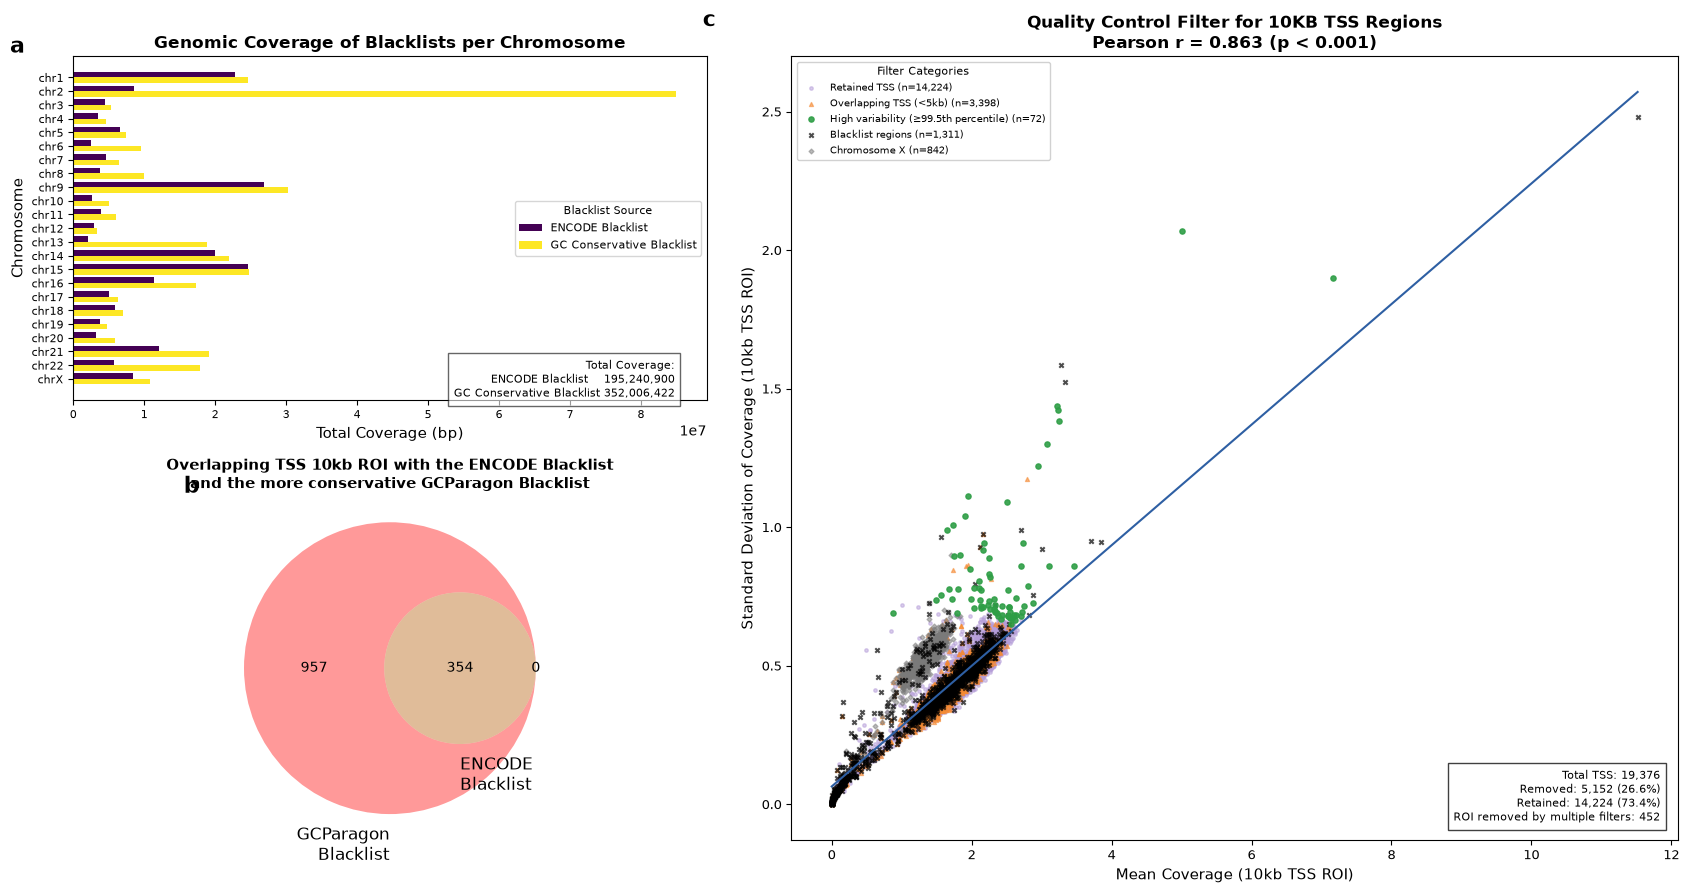

In [5]:
fig = plt.figure(figsize=(17, 9))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.4])
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[1, 0])
ax_c = fig.add_subplot(gs[:, 1])
panel_a(ax_a)
panel_b(ax_b)
r = panel_c(ax_c)
for ax, letter in [(ax_a, "a"), (ax_b, "b"), (ax_c, "c")]:
    ax.text(-0.1, 1.06, letter, transform=ax.transAxes,
            fontsize=16, fontweight="bold", va="top")
plt.tight_layout()
os.makedirs("output", exist_ok=True)
fig.savefig("output/figS2.png", dpi=200, bbox_inches="tight")
fig.savefig("output/figS2.pdf", bbox_inches="tight")
plt.show()

## Checks against the manuscript

The submitted panel reports: total 19,376; removed 5,152 (26.6%); retained
14,224 (73.4%); 452 windows removed by multiple filters; categories
blacklist 1,311 / overlapping 3,398 / chrX 842 / high variability 72;
Pearson r = 0.904. Panel a totals: ENCODE 195,195,200 bp / GC 352,006,422 bp
(the ENCODE total differs by ~0.02% from the current blacklist file —
a file-revision-level difference).

In [6]:
checks = {
    "total windows": (len(s2c), 19376),
    "removed": (int(s2c["removed"].sum()), 5152),
    "retained": (int((~s2c["removed"]).sum()), 14224),
    "blacklist": (int(s2c["in_blacklist"].sum()), 1311),
    "overlapping (<5kb)": (int(s2c["in_overlapping"].sum()), 3398),
    "chrX": (int(s2c["in_chrX"].sum()), 842),
    "high variability": (int(s2c["in_high_variability"].sum()), 72),
    "multiple filters": (int((s2c[["in_blacklist", "in_chrX", "in_overlapping",
                                   "in_high_variability"]].sum(axis=1) > 1).sum()), 452),
}
for k, (got, want) in checks.items():
    flag = "OK" if got == want else "MISMATCH"
    print(f"  {k:<20} {got:>6}  (manuscript {want:>6})  {flag}")
    assert got == want, f"{k}: {got} != {want}"
print(f"  Pearson r            {r:.3f}  (manuscript  0.904)")

  total windows         19376  (manuscript  19376)  OK
  removed                5152  (manuscript   5152)  OK
  retained              14224  (manuscript  14224)  OK
  blacklist              1311  (manuscript   1311)  OK
  overlapping (<5kb)     3398  (manuscript   3398)  OK
  chrX                    842  (manuscript    842)  OK
  high variability         72  (manuscript     72)  OK
  multiple filters        452  (manuscript    452)  OK
  Pearson r            0.863  (manuscript  0.904)
